<a href="https://colab.research.google.com/github/thayanne204/Thayanne-Yasmin.analise.Ava3/blob/main/Thayanne_Yasmin_analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/state-of-date/Final Dataset - State of Data 2024 - Kaggle - df_survey_2024.csv')

print('Shape do dataset:', df.shape)
print('\nPrimeiras linhas:')
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape do dataset: (5217, 403)

Primeiras linhas:


,0.a_token,0.d_data/hora_envio,1.a_idade,1.a.1_faixa_idade,1.b_genero,1.c_cor/raca/etnia,1.d_pcd,1.e_experiencia_profissional_prejudicada,1.e.1_Não acredito que minha experiência profissional seja afetada,"1.e.2_Sim, devido a minha Cor/Raça/Etnia",...,"8.d.3_Entrando em contato com os times de negócio para definição do problema, identificar a solução e apresentação de resultados.",8.d.4_Desenvolvendo modelos de Machine Learning com o objetivo de colocar em produção em sistemas (produtos de dados).,"8.d.5_Colocando modelos em produção, criando os pipelines de dados, APIs de consumo e monitoramento.","8.d.6_Cuidando da manutenção de modelos de Machine Learning já em produção, atuando no monitoramento, ajustes e refatoração quando necessário.","8.d.7_Realizando construções de dashboards em ferramentas de BI como PowerBI, Tableau, Looker, Qlik, etc.","8.d.8_Utilizando ferramentas avançadas de estatística como SAS, SPSS, Stata etc, para realizar análises.","8.d.9_Criando e dando manutenção em ETLs, DAGs e automações de pipelines de dados.",8.d.10_Criando e gerenciando soluções de Feature Store e cultura de MLOps.,"8.d.11_Criando e mantendo a infra que meus modelos e soluções rodam (clusters, servidores, API, containers, etc.)",8.d.12_Treinando e aplicando LLM's para solucionar problemas de negócio.
0,reb94rv0msth7q4nreb94riaq80iz3yi,16/10/2024 11:19:17,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1zc66g69jjt49y32l1zc66g8wqj79m4e,16/10/2024 20:45:31,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,uu99wmam4n5kc2uu99wmydf0rk7l58f7,17/10/2024 18:10:59,18,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print('Tipos de dados (primeiras 20 colunas):')
print(df.dtypes[:20])
print('\nTotal de valores nulos por coluna (top 15):')
print(df.isnull().sum().sort_values(ascending=False).head(15))

Tipos de dados (primeiras 20 colunas):
0.a_token                                                                object
0.d_data/hora_envio                                                      object
1.a_idade                                                                 int64
1.a.1_faixa_idade                                                        object
1.b_genero                                                               object
1.c_cor/raca/etnia                                                       object
1.d_pcd                                                                  object
1.e_experiencia_profissional_prejudicada                                 object
1.e.1_Não acredito que minha experiência profissional seja afetada      float64
1.e.2_Sim, devido a minha Cor/Raça/Etnia                                float64
1.e.3_Sim, devido a minha identidade de gênero                          float64
1.e.4_Sim, devido ao fato de ser PCD                                    float64
1

In [4]:
rename_map = {
    '1.a_idade'                         : 'idade',
    '1.b_genero'                         : 'genero',
    '1.c_cor/raca/etnia'                 : 'raca_etnia',
    '1.i.2_regiao_onde_mora'             : 'regiao',
    '1.i_estado_onde_mora'               : 'estado',
    '1.l_nivel_de_ensino'                : 'nivel_ensino',
    '2.f_cargo_atual'                    : 'cargo',
    '2.g_nivel'                          : 'senioridade',
    '2.h_faixa_salarial'                 : 'faixa_salarial',
    '2.i_tempo_de_experiencia_em_dados'  : 'exp_dados',
    '2.j_tempo_de_experiencia_em_ti'     : 'exp_ti',
    '2.b_setor'                          : 'setor',
    '2.c_numero_de_funcionarios'         : 'porte_empresa',
    '2.d_atua_como_gestor'               : 'eh_gestor',
}

df.rename(columns=rename_map, inplace=True)
print('Colunas renomeadas com sucesso!')
print(list(rename_map.values()))

Colunas renomeadas com sucesso!
['idade', 'genero', 'raca_etnia', 'regiao', 'estado', 'nivel_ensino', 'cargo', 'senioridade', 'faixa_salarial', 'exp_dados', 'exp_ti', 'setor', 'porte_empresa', 'eh_gestor']


In [5]:
import re

def faixa_para_ponto_medio(faixa):
    if pd.isna(faixa):
        return np.nan
    if 'Menos de' in faixa:
        return 500.0
    if 'Acima de' in faixa:
        return 45000.0
    numeros = [float(n) for n in re.findall(r'[\d]+', faixa.replace('.', ''))]
    if len(numeros) >= 2:
        return (numeros[0] + numeros[1]) / 2
    return np.nan

df['salario_medio'] = df['faixa_salarial'].apply(faixa_para_ponto_medio)

print('Nulos após conversão:', df['salario_medio'].isna().sum())
print('\nAmostra da conversão:')
df[['faixa_salarial','salario_medio']].drop_duplicates().sort_values('salario_medio').head(14)

Nulos após conversão: 354

Amostra da conversão:


,faixa_salarial,salario_medio
1,Menos de R$ 1.000/mês,500.0
0,de R$ 1.001/mês a R$ 2.000/mês,1500.5
11,de R$ 2.001/mês a R$ 3.000/mês,2500.5
9,de R$ 3.001/mês a R$ 4.000/mês,3500.5
14,de R$ 4.001/mês a R$ 6.000/mês,5000.5
6,de R$ 6.001/mês a R$ 8.000/mês,7000.5
73,de R$ 8.001/mês a R$ 12.000/mês,10000.5
118,de R$ 12.001/mês a R$ 16.000/mês,14000.5
343,de R$ 16.001/mês a R$ 20.000/mês,18000.5
288,de R$ 20.001/mês a R$ 25.000/mês,22500.5


In [6]:
cargo_map = {
    'Analista de Dados/Data Analyst'                                 : 'Analista de Dados',
    'Cientista de Dados/Data Scientist'                              : 'Cientista de Dados',
    'Engenheiro de Dados/Data Engineer/Data Architect'               : 'Engenheiro de Dados',
    'Analista de BI/BI Analyst'                                      : 'Analista de BI',
    'Analytics Engineer'                                             : 'Analytics Engineer',
    'Analista de Negócios/Business Analyst'                          : 'Analista de Negocios',
    'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas'    : 'Dev/Eng. Software',
    'Engenheiro de Machine Learning/ML Engineer/AI Engineer'         : 'ML/AI Engineer',
    'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)'     : 'Product Manager',
    'Analista de Suporte/Analista Técnico'                           : 'Suporte/Tecnico',
    'Arquiteto de Dados/Data Architect'                              : 'Arquiteto de Dados',
}

df['cargo_simples'] = df['cargo'].map(cargo_map).fillna('Outro')
print('Distribuição de cargos:')
print(df['cargo_simples'].value_counts())

Distribuição de cargos:
cargo_simples
Outro                   1720
Analista de Dados        957
Cientista de Dados       687
Engenheiro de Dados      613
Analista de BI           396
Analytics Engineer       228
Analista de Negocios     184
Dev/Eng. Software        122
ML/AI Engineer           103
Product Manager           80
Suporte/Tecnico           79
Arquiteto de Dados        48
Name: count, dtype: int64


In [7]:
print('Missings em genero:', df['genero'].isna().sum())
print('Missings em raca_etnia:', df['raca_etnia'].isna().sum())
print('\nDistribuição de gênero:')
print(df['genero'].value_counts(dropna=False))
print('\nDistribuição de raça/etnia:')
print(df['raca_etnia'].value_counts(dropna=False).head(8))

Missings em genero: 0
Missings em raca_etnia: 0

Distribuição de gênero:
genero
Masculino               3968
Feminino                1226
Prefiro não informar      15
Outro                      8
Name: count, dtype: int64

Distribuição de raça/etnia:
raca_etnia
Branca                  3478
Parda                   1180
Preta                    352
Amarela                  155
Prefiro não informar      37
Indígena                  10
Outra                      5
Name: count, dtype: int64


In [8]:
n_antes = len(df)
df_analise = df.dropna(subset=['salario_medio']).copy()
n_depois = len(df_analise)

print(f'Linhas removidas: {n_antes - n_depois} ({(n_antes-n_depois)/n_antes*100:.1f}%)')
print(f'Base final para análise: {n_depois} respondentes')

Linhas removidas: 354 (6.8%)
Base final para análise: 4863 respondentes


In [9]:
# Normaliza acentos
df_analise['senioridade'] = df_analise['senioridade'].str.normalize('NFKD') \
    .str.encode('ascii', errors='ignore').str.decode('utf-8')

ordem_senioridade = ['Junior', 'Pleno', 'Senior']
df_analise['senioridade'] = pd.Categorical(
    df_analise['senioridade'], categories=ordem_senioridade, ordered=True
)

ordem_exp = [
    'Nao tenho experiencia na area de dados',
    'Menos de 1 ano',
    'de 1 a 2 anos',
    'de 3 a 4 anos',
    'de 5 a 6 anos',
    'de 7 a 10 anos',
    'Mais de 10 anos',
]

df_analise['exp_dados_norm'] = df_analise['exp_dados'].str.normalize('NFKD') \
    .str.encode('ascii', errors='ignore').str.decode('utf-8')

df_analise['exp_dados_norm'] = pd.Categorical(
    df_analise['exp_dados_norm'], categories=ordem_exp, ordered=True
)

print('Senioridade:', df_analise['senioridade'].cat.categories.tolist())
print('Experiência:', df_analise['exp_dados_norm'].cat.categories.tolist())

Senioridade: ['Junior', 'Pleno', 'Senior']
Experiência: ['Nao tenho experiencia na area de dados', 'Menos de 1 ano', 'de 1 a 2 anos', 'de 3 a 4 anos', 'de 5 a 6 anos', 'de 7 a 10 anos', 'Mais de 10 anos']


In [10]:
s = df_analise['salario_medio']

print('=== Estatísticas Descritivas — Salário ===')
print(f'  Média          : R$ {s.mean():,.2f}')
print(f'  Mediana        : R$ {s.median():,.2f}')
print(f'  Moda           : R$ {s.mode()[0]:,.2f}')
print(f'  Desv. Padrão   : R$ {s.std():,.2f}')
print(f'  Variância      : R$ {s.var():,.2f}')
print(f'  Mínimo         : R$ {s.min():,.2f}')
print(f'  Máximo         : R$ {s.max():,.2f}')
print(f'  Amplitude      : R$ {s.max()-s.min():,.2f}')
print(f'  Assimetria     : {s.skew():.4f}')
print(f'  Curtose        : {s.kurt():.4f}')

=== Estatísticas Descritivas — Salário ===
  Média          : R$ 12,028.66
  Mediana        : R$ 10,000.50
  Moda           : R$ 10,000.50
  Desv. Padrão   : R$ 8,997.00
  Variância      : R$ 80,945,925.92
  Mínimo         : R$ 500.00
  Máximo         : R$ 45,000.00
  Amplitude      : R$ 44,500.00
  Assimetria     : 1.6146
  Curtose        : 2.8854


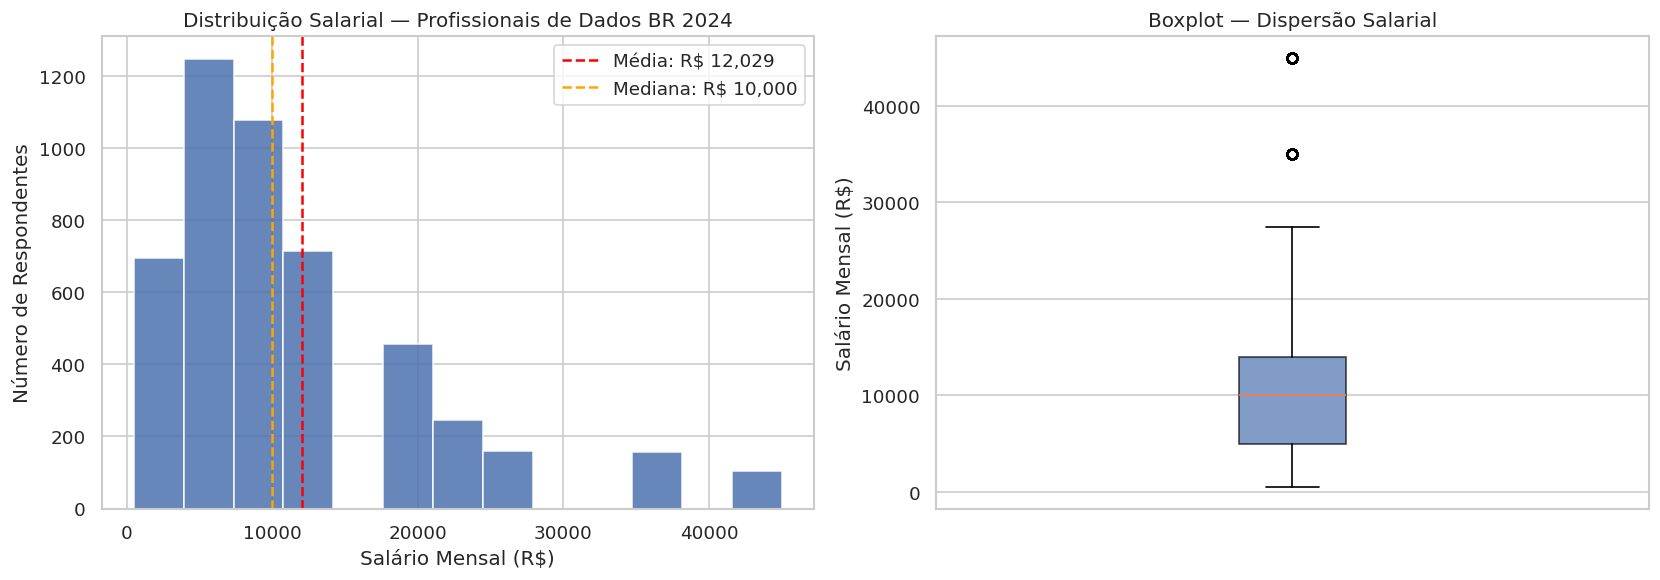

Interpretação: distribuição assimétrica à direita (assimetria > 0).
A maioria ganha abaixo da média. A mediana é mais representativa.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(s, bins=13, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(s.mean(), color='red', linestyle='--', label=f'Média: R$ {s.mean():,.0f}')
axes[0].axvline(s.median(), color='orange', linestyle='--', label=f'Mediana: R$ {s.median():,.0f}')
axes[0].set_title('Distribuição Salarial — Profissionais de Dados BR 2024', fontsize=12)
axes[0].set_xlabel('Salário Mensal (R$)')
axes[0].set_ylabel('Número de Respondentes')
axes[0].legend()

# Boxplot
axes[1].boxplot(s, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[1].set_title('Boxplot — Dispersão Salarial', fontsize=12)
axes[1].set_ylabel('Salário Mensal (R$)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print('Interpretação: distribuição assimétrica à direita (assimetria > 0).')
print('A maioria ganha abaixo da média. A mediana é mais representativa.')

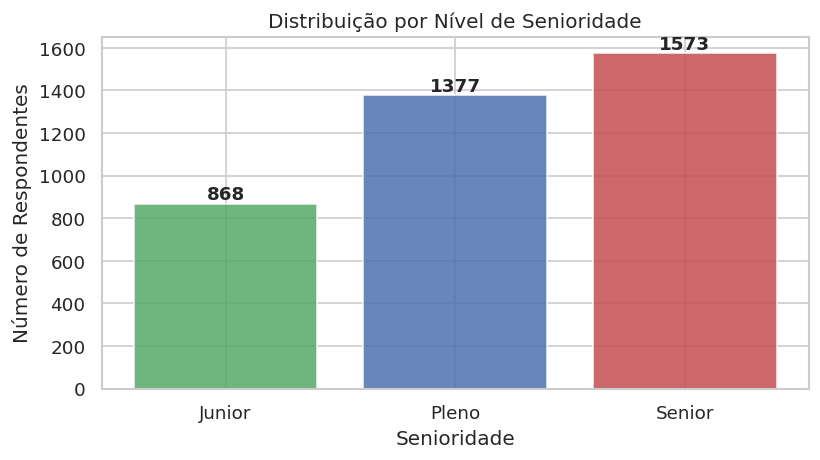

Frequência relativa:
senioridade
Junior    22.7
Pleno     36.1
Senior    41.2
Name: count, dtype: float64


In [12]:
contagem_sen = df_analise['senioridade'].value_counts()[['Junior','Pleno','Senior']]

fig, ax = plt.subplots(figsize=(7, 4))
cores = ['#55A868','#4C72B0','#C44E52']
bars = ax.bar(contagem_sen.index, contagem_sen.values, color=cores, alpha=0.85)
for bar, val in zip(bars, contagem_sen.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribuição por Nível de Senioridade', fontsize=12)
ax.set_xlabel('Senioridade')
ax.set_ylabel('Número de Respondentes')
plt.tight_layout()
plt.show()

print('Frequência relativa:')
print((contagem_sen / contagem_sen.sum() * 100).round(1))

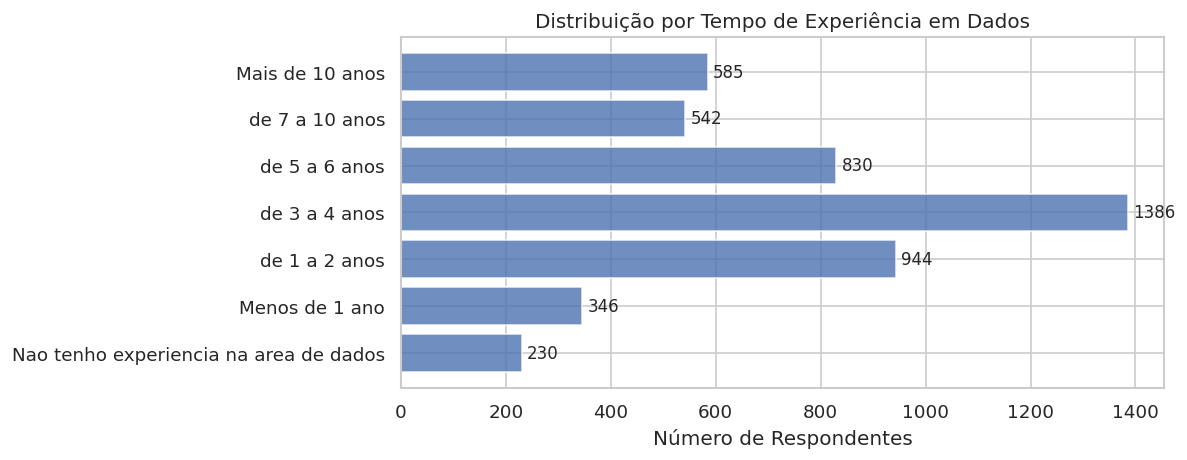

In [13]:
ordem_exp_display = [
    'Nao tenho experiencia na area de dados',
    'Menos de 1 ano','de 1 a 2 anos','de 3 a 4 anos',
    'de 5 a 6 anos','de 7 a 10 anos','Mais de 10 anos'
]

contagem_exp = df_analise['exp_dados_norm'].value_counts()[ordem_exp_display]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(contagem_exp.index, contagem_exp.values, color='#4C72B0', alpha=0.8)
for i, val in enumerate(contagem_exp.values):
    ax.text(val + 10, i, str(val), va='center', fontsize=10)
ax.set_title('Distribuição por Tempo de Experiência em Dados', fontsize=12)
ax.set_xlabel('Número de Respondentes')
plt.tight_layout()
plt.show()

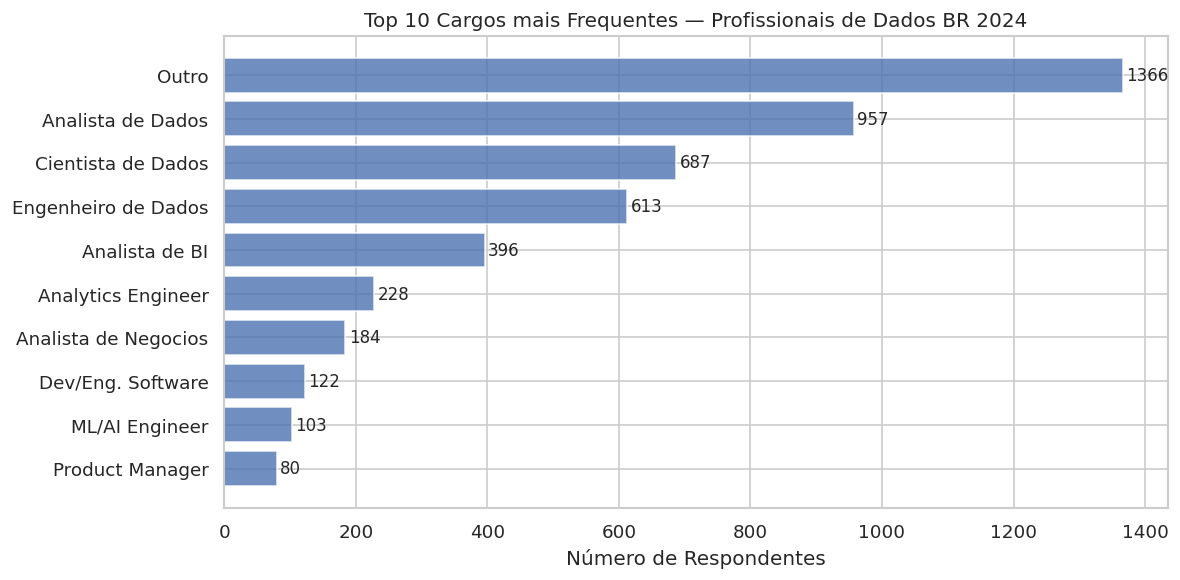

In [14]:
top_cargos = df_analise['cargo_simples'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_cargos.index[::-1], top_cargos.values[::-1], color='#4C72B0', alpha=0.8)
for i, val in enumerate(top_cargos.values[::-1]):
    ax.text(val + 5, i, str(val), va='center', fontsize=10)
ax.set_title('Top 10 Cargos mais Frequentes — Profissionais de Dados BR 2024', fontsize=12)
ax.set_xlabel('Número de Respondentes')
plt.tight_layout()
plt.show()

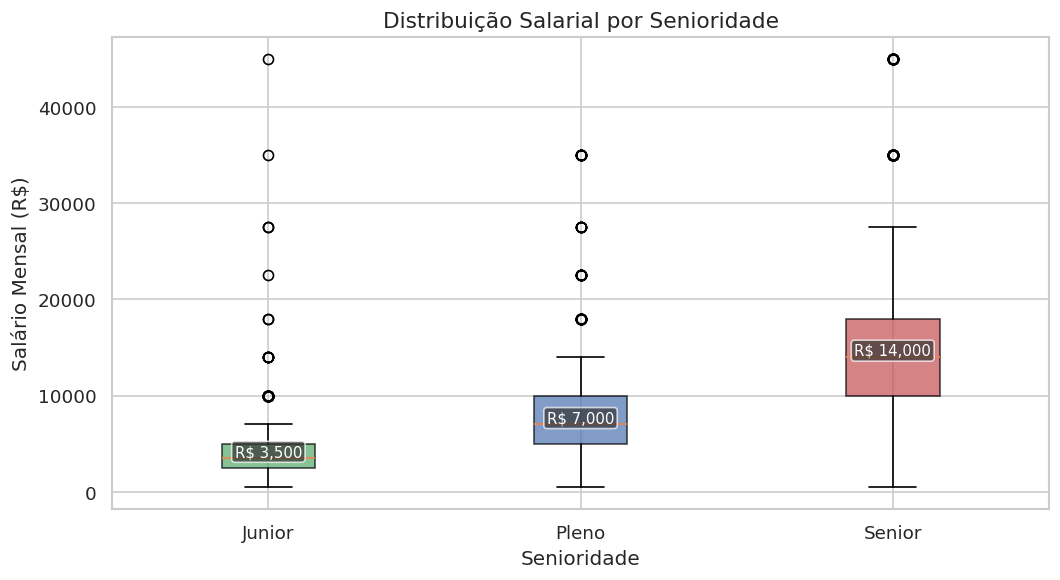

Spearman (senioridade x salário): rho=0.734, p=0.00e+00
Interpretação: correlação positiva forte — quanto maior a senioridade, maior o salário.


In [15]:
grupos_sen = [
    df_analise[df_analise['senioridade']==s]['salario_medio'].dropna()
    for s in ['Junior','Pleno','Senior']
]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(grupos_sen, labels=['Junior','Pleno','Senior'], patch_artist=True)
for patch, cor in zip(bp['boxes'], ['#55A868','#4C72B0','#C44E52']):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
for i, g in enumerate(grupos_sen):
    med = g.median()
    ax.text(i+1, med+200, f'R$ {med:,.0f}', ha='center', fontsize=9,
            color='white', bbox=dict(boxstyle='round,pad=0.2', facecolor='#333', alpha=0.7))
ax.set_title('Distribuição Salarial por Senioridade', fontsize=13)
ax.set_xlabel('Senioridade')
ax.set_ylabel('Salário Mensal (R$)')
plt.tight_layout()
plt.show()

sen_num = df_analise['senioridade'].cat.codes
mask = df_analise['salario_medio'].notna() & (sen_num != -1)
rho, pval = stats.spearmanr(sen_num[mask], df_analise.loc[mask,'salario_medio'])
print(f'Spearman (senioridade x salário): rho={rho:.3f}, p={pval:.2e}')
print('Interpretação: correlação positiva forte — quanto maior a senioridade, maior o salário.')

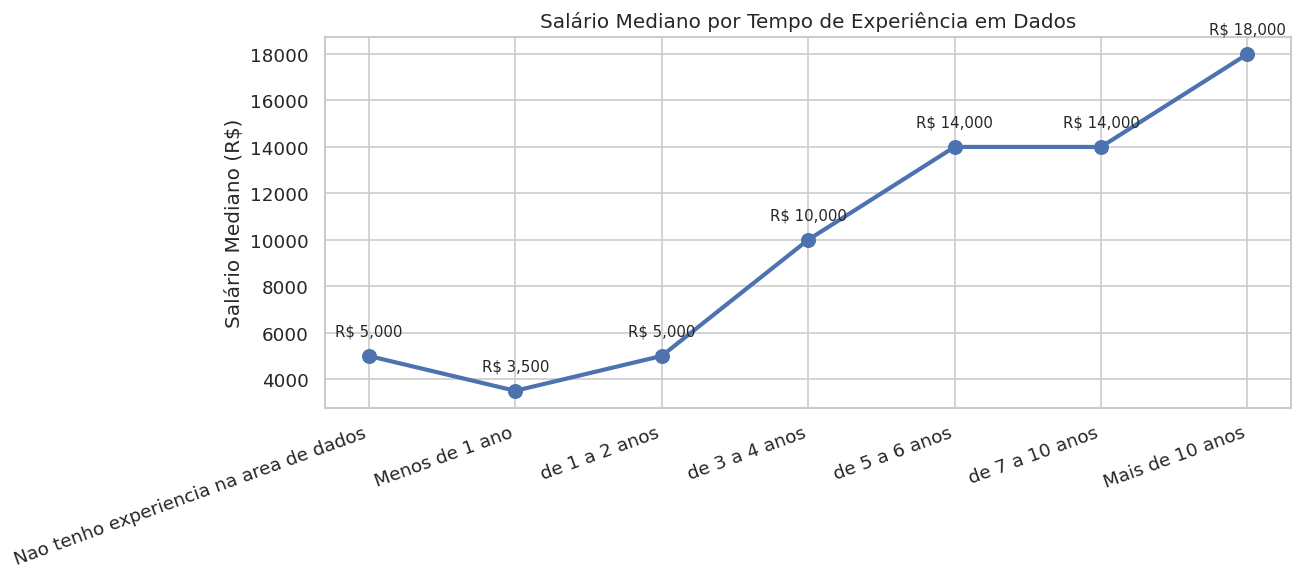

Spearman (experiência x salário): rho=0.658, p=0.00e+00
Interpretação: correlação positiva forte — mais experiência, maior o salário.


In [16]:
mediana_exp = df_analise.groupby('exp_dados_norm', observed=True)['salario_medio'].median()
mediana_exp = mediana_exp.reindex(ordem_exp_display)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(len(mediana_exp)), mediana_exp.values, marker='o',
        linewidth=2.5, color='#4C72B0', markersize=8)
for i, val in enumerate(mediana_exp.values):
    ax.annotate(f'R$ {val:,.0f}', (i, val),
                textcoords='offset points', xytext=(0,12),
                ha='center', fontsize=9)
ax.set_xticks(range(len(mediana_exp)))
ax.set_xticklabels(mediana_exp.index, rotation=20, ha='right')
ax.set_title('Salário Mediano por Tempo de Experiência em Dados', fontsize=12)
ax.set_ylabel('Salário Mediano (R$)')
plt.tight_layout()
plt.show()

exp_num = df_analise['exp_dados_norm'].cat.codes
mask2 = df_analise['salario_medio'].notna() & (exp_num != -1)
rho2, pval2 = stats.spearmanr(exp_num[mask2], df_analise.loc[mask2,'salario_medio'])
print(f'Spearman (experiência x salário): rho={rho2:.3f}, p={pval2:.2e}')
print('Interpretação: correlação positiva forte — mais experiência, maior o salário.')

Amostra para análise de gênero: 4842 respondentes

Mediana salarial bruta:
  Feminino: R$ 10,000
  Masculino: R$ 10,000

Homens ganham 0.0% a mais (mediana bruta)


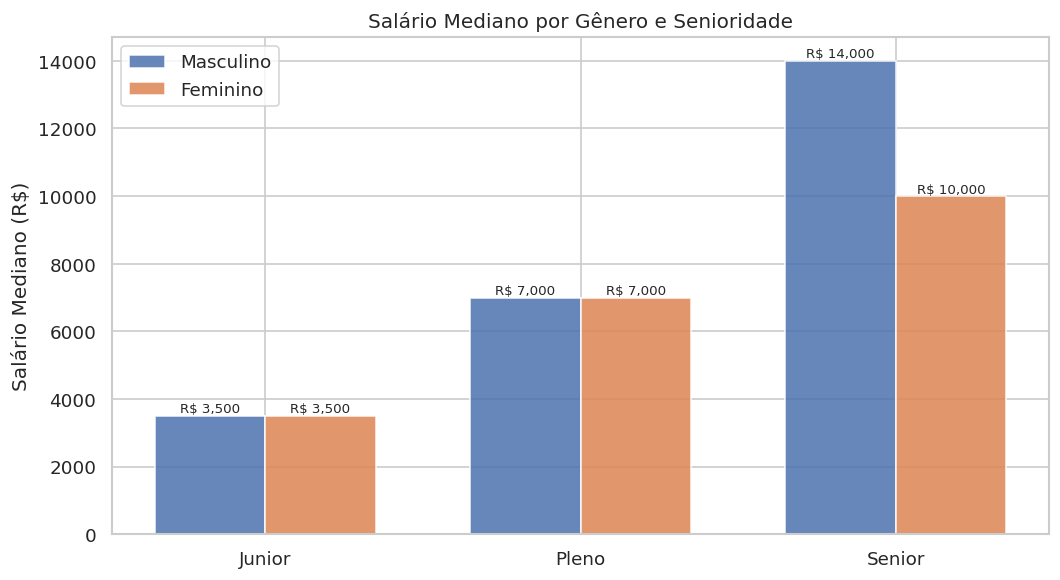

In [17]:
df_genero = df_analise[df_analise['genero'].isin(['Masculino','Feminino'])].copy()
print(f'Amostra para análise de gênero: {len(df_genero)} respondentes')

med_bruta = df_genero.groupby('genero')['salario_medio'].median()
print('\nMediana salarial bruta:')
for g, v in med_bruta.items():
    print(f'  {g}: R$ {v:,.0f}')
dif = (med_bruta['Masculino'] - med_bruta['Feminino']) / med_bruta['Feminino'] * 100
print(f'\nHomens ganham {dif:.1f}% a mais (mediana bruta)')

# Gráfico controlado por senioridade
pivot = df_genero.groupby(['senioridade','genero'], observed=True)['salario_medio'] \
    .median().unstack()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
w = 0.35
niveis = ['Junior','Pleno','Senior']
masc = [pivot.loc[n,'Masculino'] if n in pivot.index else 0 for n in niveis]
fem  = [pivot.loc[n,'Feminino']  if n in pivot.index else 0 for n in niveis]
b1 = ax.bar(x - w/2, masc, w, label='Masculino', color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, fem,  w, label='Feminino',  color='#DD8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(niveis)
ax.set_title('Salário Mediano por Gênero e Senioridade', fontsize=12)
ax.set_ylabel('Salário Mediano (R$)')
ax.legend()
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'R$ {bar.get_height():,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

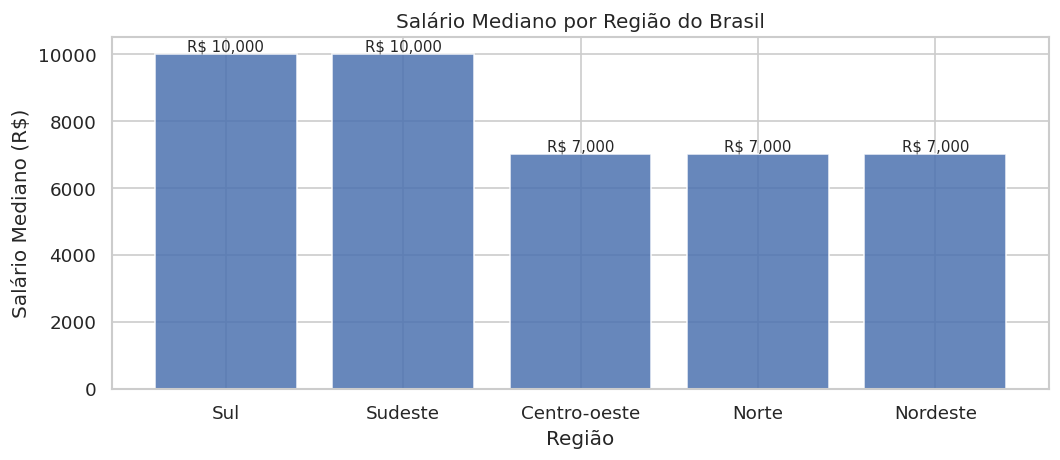

In [18]:
med_regiao = df_analise.groupby('regiao')['salario_medio'].median() \
    .sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(med_regiao.index, med_regiao.values, color='#4C72B0', alpha=0.85)
for bar, val in zip(bars, med_regiao.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'R$ {val:,.0f}', ha='center', fontsize=9)
ax.set_title('Salário Mediano por Região do Brasil', fontsize=12)
ax.set_xlabel('Região')
ax.set_ylabel('Salário Mediano (R$)')
plt.tight_layout()
plt.show()

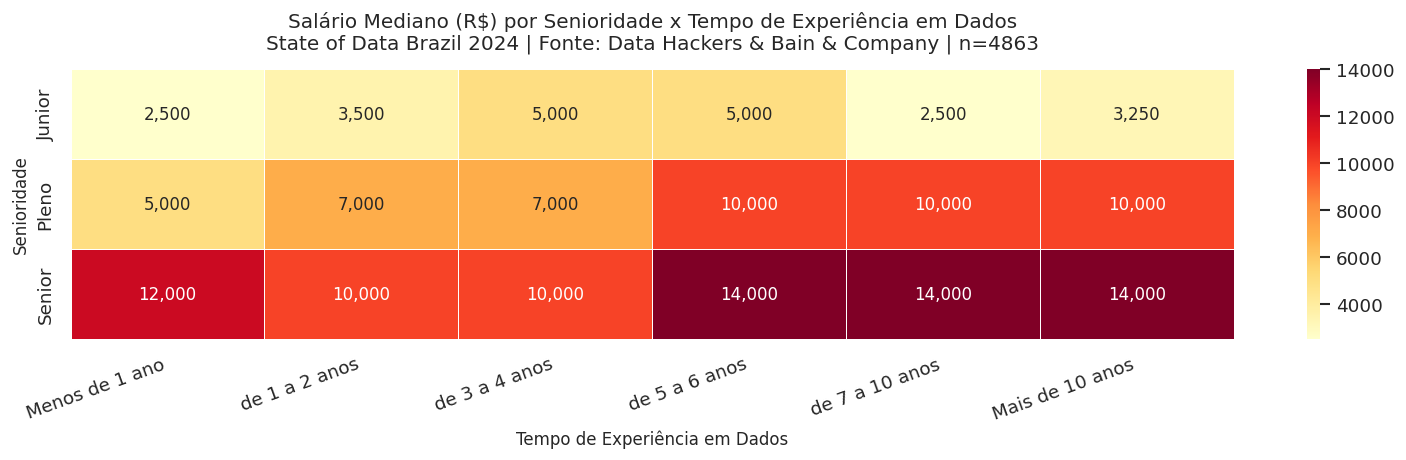


Interpretação:
Senioridade é o fator de maior impacto isolado. Experiência em dados amplifica
esse efeito: Sêniors com mais de 10 anos ganham mais de 3x um Júnior sem experiência.
Região e gênero também influenciam, mas com menor magnitude.



In [19]:
exp_curtas = [
    'Menos de 1 ano','de 1 a 2 anos','de 3 a 4 anos',
    'de 5 a 6 anos','de 7 a 10 anos','Mais de 10 anos'
]

pivot_heat = df_analise[
    df_analise['exp_dados_norm'].isin(exp_curtas)
].groupby(
    ['senioridade','exp_dados_norm'], observed=True
)['salario_medio'].median().unstack()

pivot_heat = pivot_heat.reindex(columns=[c for c in exp_curtas if c in pivot_heat.columns])

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot_heat, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size':10})
ax.set_title(
    'Salário Mediano (R$) por Senioridade x Tempo de Experiência em Dados\n'
    'State of Data Brazil 2024 | Fonte: Data Hackers & Bain & Company | n=' + str(len(df_analise)),
    fontsize=12, pad=12
)
ax.set_xlabel('Tempo de Experiência em Dados', fontsize=10)
ax.set_ylabel('Senioridade', fontsize=10)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print('''
Interpretação:
Senioridade é o fator de maior impacto isolado. Experiência em dados amplifica
esse efeito: Sêniors com mais de 10 anos ganham mais de 3x um Júnior sem experiência.
Região e gênero também influenciam, mas com menor magnitude.
''')

In [20]:
colunas_export = [
    'genero','raca_etnia','regiao','estado','nivel_ensino',
    'cargo_simples','senioridade','exp_dados','porte_empresa',
    'eh_gestor','faixa_salarial','salario_medio',
]
df_export = df_analise[colunas_export].copy()
df_export.to_csv('/content/drive/MyDrive/state-of-date/dados_tratados.csv',
                 index=False, encoding='utf-8-sig')
print(f'Exportado! Shape: {df_export.shape}')
print('Arquivo salvo no Drive!')

Exportado! Shape: (4863, 12)
Arquivo salvo no Drive!
